# 04 Feature Engineering and XGBoost

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import warnings
warnings.filterwarnings("ignore")
import sys
import os
sys.path.append("..")

from src.ingest import TICKERS, ALL_TICKERS
from src.features import build_all_features, build_features
from src.evaluate import evaluate, compare_models

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 120

PROCESSED_DIR = "../data/processed/"
FIGURES_DIR = "../report/figures/"
os.makedirs(FIGURES_DIR, exist_ok=True)

In [25]:
print("Building features for all tickers")
data = build_all_features(PROCESSED_DIR, ALL_TICKERS)
print(f"\nFeature columns: {[c for c in data.columns if c not in ['ticker', 'sector']]}")

Building features for all tickers
  AAPL: 1487 rows, 13 columns
  MSFT: 1487 rows, 13 columns
  GOOGL: 1487 rows, 13 columns
  JPM: 1487 rows, 13 columns
  GS: 1487 rows, 13 columns
  BAC: 1487 rows, 13 columns
  XOM: 1487 rows, 13 columns
  CVX: 1487 rows, 13 columns
  AMZN: 1487 rows, 13 columns
  WMT: 1487 rows, 13 columns
  NVDA: 1487 rows, 13 columns
  AMD: 1487 rows, 13 columns
  JNJ: 1487 rows, 13 columns
  PFE: 1487 rows, 13 columns

Total: 20818 rows across 14 tickers

Feature columns: ['return', 'return_lag_1', 'return_lag_5', 'return_lag_10', 'return_lag_20', 'rolling_vol_5', 'rolling_vol_20', 'volume_ratio', 'ma_crossover', 'rsi_14', 'target']


In [26]:
print(data.head())

              return  return_lag_1  return_lag_5  return_lag_10  \
Date                                                              
2019-02-01  0.000481      0.007201      0.033137       0.005938   
2019-02-04  0.028405      0.000481     -0.009255       0.006160   
2019-02-05  0.017109      0.028405     -0.010365      -0.022447   
2019-02-06  0.000345      0.017109      0.068335       0.004045   
2019-02-07 -0.018939      0.000345      0.007201      -0.007927   

            return_lag_20  rolling_vol_5  rolling_vol_20  volume_ratio  \
Date                                                                     
2019-02-01      -0.099607       0.519188        0.340144      0.807430   
2019-02-04       0.042689       0.493559        0.324313      0.758561   
2019-02-05      -0.002226       0.425021        0.323942      0.893097   
2019-02-06       0.019063       0.190901        0.322577      0.834285   
2019-02-07       0.016981       0.287113        0.333526      0.990402   

           

## 1. Train and test split

In [27]:
feature_cols = ['return_lag_1', 'return_lag_5', 'return_lag_10', 'return_lag_20',
                'rolling_vol_5', 'rolling_vol_20', 'volume_ratio', 'ma_crossover', 'rsi_14']

cutoff = data.index.unique().sort_values()[int(len(data.index.unique()) * 0.8)]
print(f"Train cutoff: {cutoff.date()}")

train_data = data[data.index <= cutoff]
test_data = data[data.index > cutoff]

X_train = train_data[feature_cols]
y_train = train_data["target"]
X_test = test_data[feature_cols]
y_test = test_data["target"]

print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows")
print(f"Train period: {train_data.index.min().date()} to {train_data.index.max().date()}")
print(f"Test period:  {test_data.index.min().date()} to {test_data.index.max().date()}")

Train cutoff: 2023-10-23
Train: 16660 rows | Test: 4158 rows
Train period: 2019-02-01 to 2023-10-23
Test period:  2023-10-24 to 2024-12-27


## 2. Baseline XGBoost model

I am starting with default parameters to get a baseline first

In [28]:
model_base = XGBRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model_base.fit(X_train, y_train)
preds_base = model_base.predict(X_test)

naive_preds = np.zeros(len(y_test))

compare_models([
    evaluate(y_test, preds_base, "XGBoost Base"),
    evaluate(y_test, naive_preds, "Naive"),
])


Model                      RMSE        MAE       MAPE
XGBoost Base           0.018707   0.012764    196.68%
Naive                  0.017675   0.011951    100.00%


## 3. Hyperparameter tuning with time series cross validation

In [29]:
tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    "n_estimators": [100, 300],
    "max_depth": [3, 5],
    "learning_rate": [0.01, 0.05],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
    "min_child_weight": [5, 10]
}

xgb = XGBRegressor(random_state=42, n_jobs=-1)

search = GridSearchCV(
    xgb,
    param_grid,
    cv=tscv,
    scoring="neg_root_mean_squared_error",
    verbose=1,
    n_jobs=-1
)

search.fit(X_train, y_train)

print(f"\nBest params: {search.best_params_}")
print(f"Best CV RMSE: {-search.best_score_:.6f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 300, 'subsample': 0.8}
Best CV RMSE: 0.021718


In [30]:
best_model = XGBRegressor(
    colsample_bytree=0.8,
    learning_rate=0.01,
    max_depth=5,
    min_child_weight=5,
    n_estimators=300,
    subsample=0.8,
    random_state=42
)

best_model.fit(X_train, y_train)
preds_tuned = best_model.predict(X_test)

naive_preds = np.zeros(len(y_test))

compare_models([
    evaluate(y_test, preds_tuned, "XGBoost Tuned"),
    evaluate(y_test, naive_preds, "Naive"),
])


Model                      RMSE        MAE       MAPE
XGBoost Tuned          0.017705   0.011943    114.85%
Naive                  0.017675   0.011951    100.00%


Baseline XGBoost with default settings loses to just predicting zero every day. This tells us the default model is not learning anything useful yet.

## 4. Feature Importance

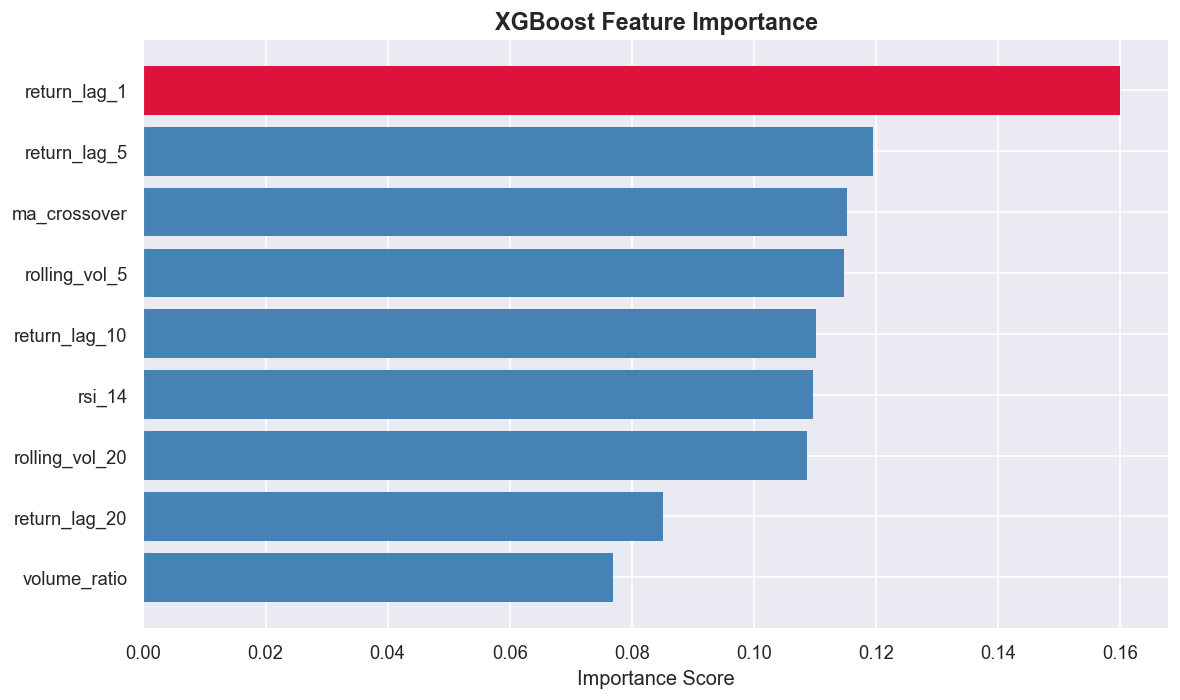

In [31]:
importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["steelblue" if v < importances.max() else "crimson" for v in importances.values]
ax.barh(importances.index, importances.values, color=colors, edgecolor="none")
ax.set_title("XGBoost Feature Importance", fontsize=14, fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}12_feature_importance.png", bbox_inches="tight")
plt.show()

## 5. Forecast vs actual plot

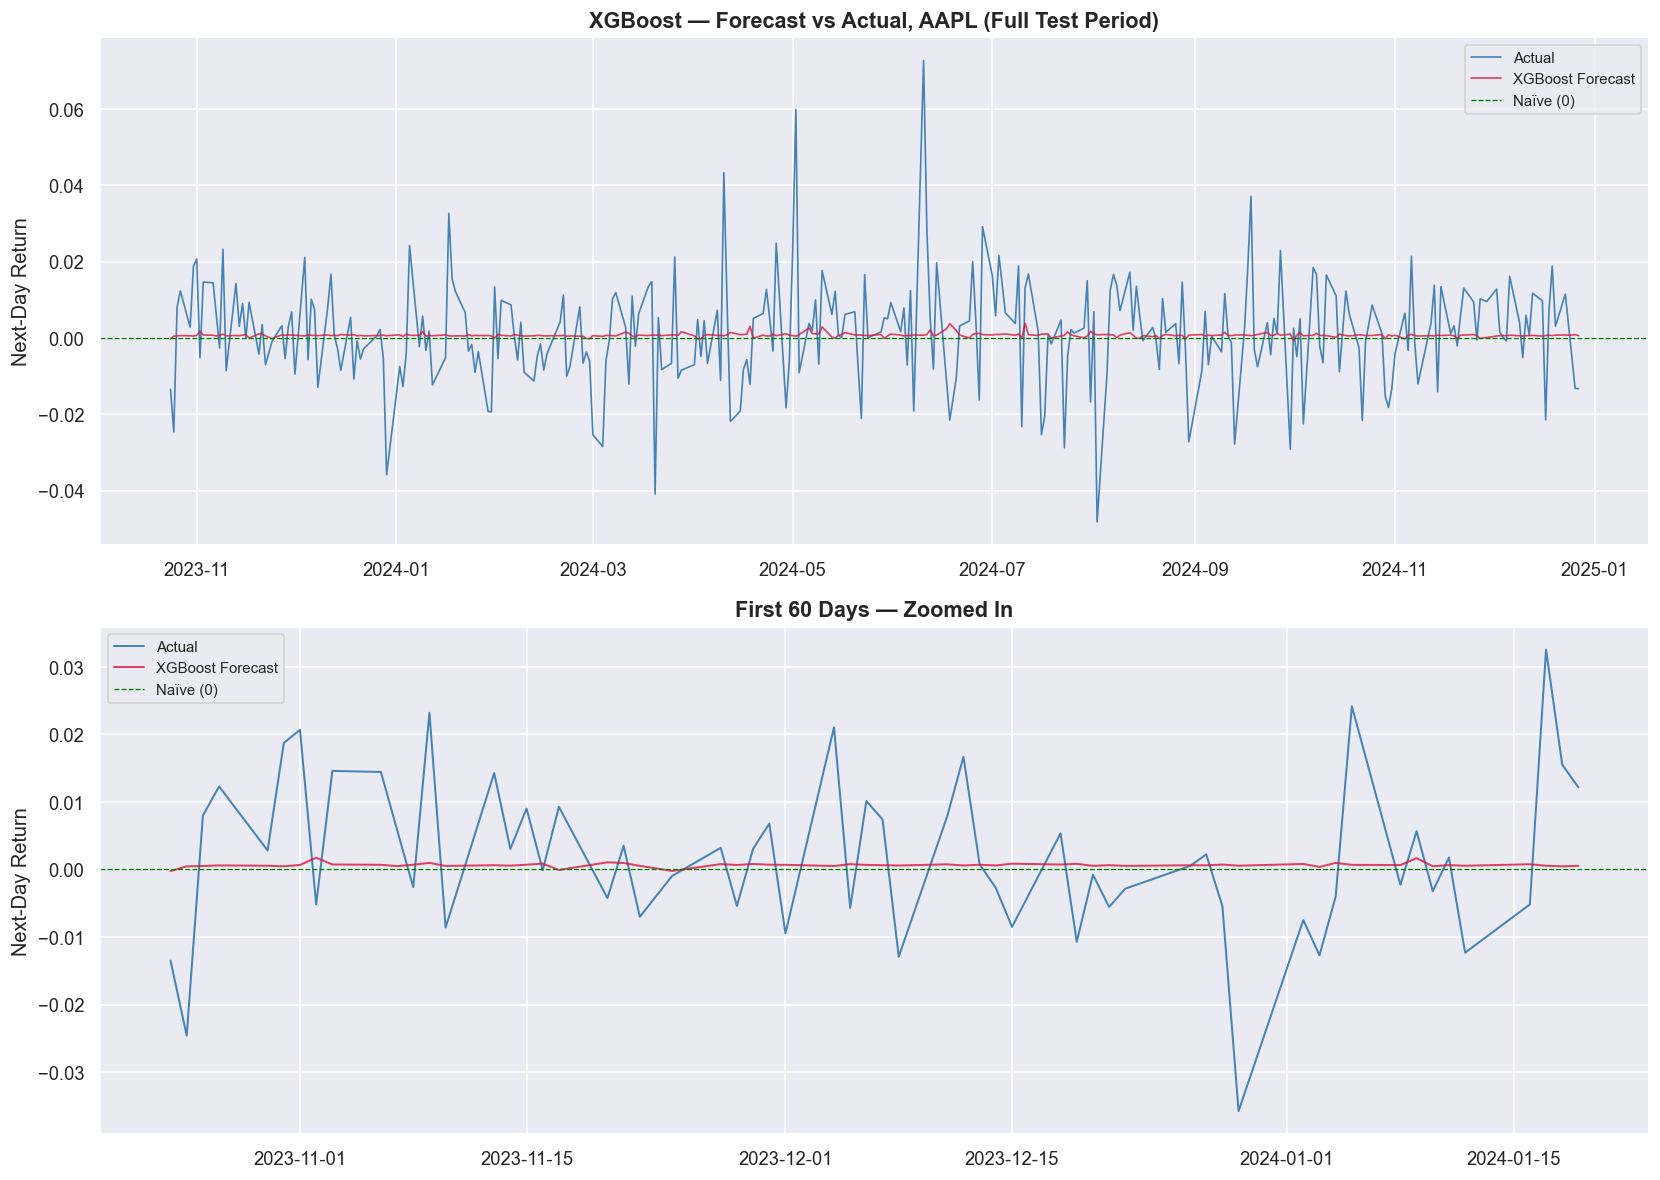

In [32]:
aapl_test = test_data[test_data["ticker"] == "AAPL"]
aapl_preds = best_model.predict(aapl_test[feature_cols])

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(aapl_test.index, aapl_test["target"].values, label="Actual", color="steelblue", linewidth=1)
axes[0].plot(aapl_test.index, aapl_preds, label="XGBoost Forecast", color="crimson", linewidth=1, alpha=0.8)
axes[0].axhline(0, color="green", linewidth=0.8, linestyle="--", label="Naïve (0)")
axes[0].set_title("XGBoost — Forecast vs Actual, AAPL (Full Test Period)", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Next-Day Return")
axes[0].legend(fontsize=9)

axes[1].plot(aapl_test.index[:60], aapl_test["target"].values[:60], label="Actual", color="steelblue", linewidth=1.2)
axes[1].plot(aapl_test.index[:60], aapl_preds[:60], label="XGBoost Forecast", color="crimson", linewidth=1.2, alpha=0.8)
axes[1].axhline(0, color="green", linewidth=0.8, linestyle="--", label="Naïve (0)")
axes[1].set_title("First 60 Days — Zoomed In", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Next-Day Return")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}13_xgboost_forecast.png", bbox_inches="tight")
plt.show()

## 6. Per sector performance

In [33]:
sector_results = []

for sector, tickers in TICKERS.items():
    sector_test = test_data[test_data["ticker"].isin(tickers)]
    sector_preds = best_model.predict(sector_test[feature_cols])
    naive_preds_s = np.zeros(len(sector_test))

    rmse_xgb = np.sqrt(mean_squared_error(sector_test["target"], sector_preds))
    rmse_naive = np.sqrt(mean_squared_error(sector_test["target"], naive_preds_s))
    mae_xgb = mean_absolute_error(sector_test["target"], sector_preds)

    sector_results.append({
        "sector": sector,
        "XGB RMSE": round(rmse_xgb, 6),
        "Naive RMSE": round(rmse_naive, 6),
        "MAE": round(mae_xgb, 6),
        "beats naive": rmse_xgb < rmse_naive
    })

sector_df = pd.DataFrame(sector_results).set_index("sector")
print(sector_df.to_string())

                XGB RMSE  Naive RMSE       MAE  beats naive
sector                                                     
tech            0.015014    0.015016  0.010764         True
finance         0.015256    0.015326  0.010387         True
energy          0.012349    0.012311  0.009248        False
consumer        0.015178    0.015211  0.010652         True
semiconductors  0.030985    0.030802  0.022788        False
healthcare      0.012806    0.012835  0.009187         True


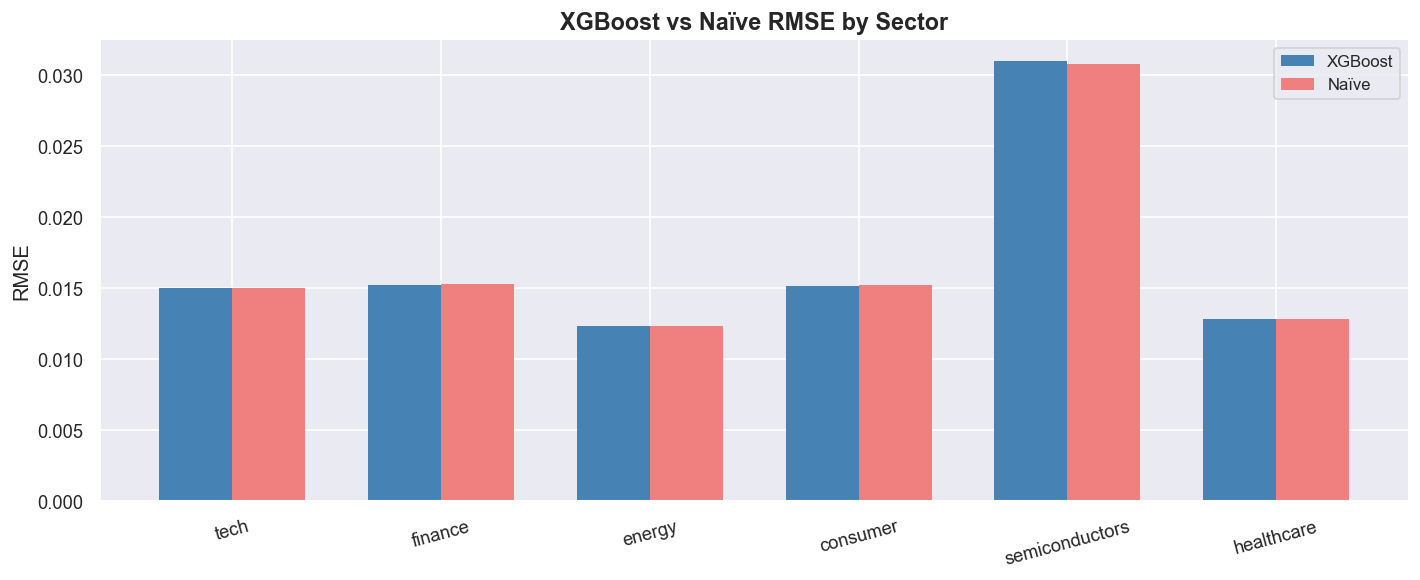

In [34]:
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(sector_df))
width = 0.35

bars1 = ax.bar(x - width/2, sector_df["XGB RMSE"], width, label="XGBoost", color="steelblue", edgecolor="none")
bars2 = ax.bar(x + width/2, sector_df["Naive RMSE"], width, label="Naïve", color="lightcoral", edgecolor="none")

ax.set_title("XGBoost vs Naïve RMSE by Sector", fontsize=14, fontweight="bold")
ax.set_ylabel("RMSE")
ax.set_xticks(x)
ax.set_xticklabels(sector_df.index, rotation=15)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}14_sector_performance.png", bbox_inches="tight")
plt.show()

## 7. Model Comparison

           Model     RMSE      MAE   MAPE (%)       Beats Naïve
Naïve (baseline) 0.017675 0.011951 100.000000                 —
    ARIMA(1,0,0) 0.013851 0.010115 120.040000 No (on full test)
 XGBoost (tuned) 0.017705 0.011943 114.853074        Marginally


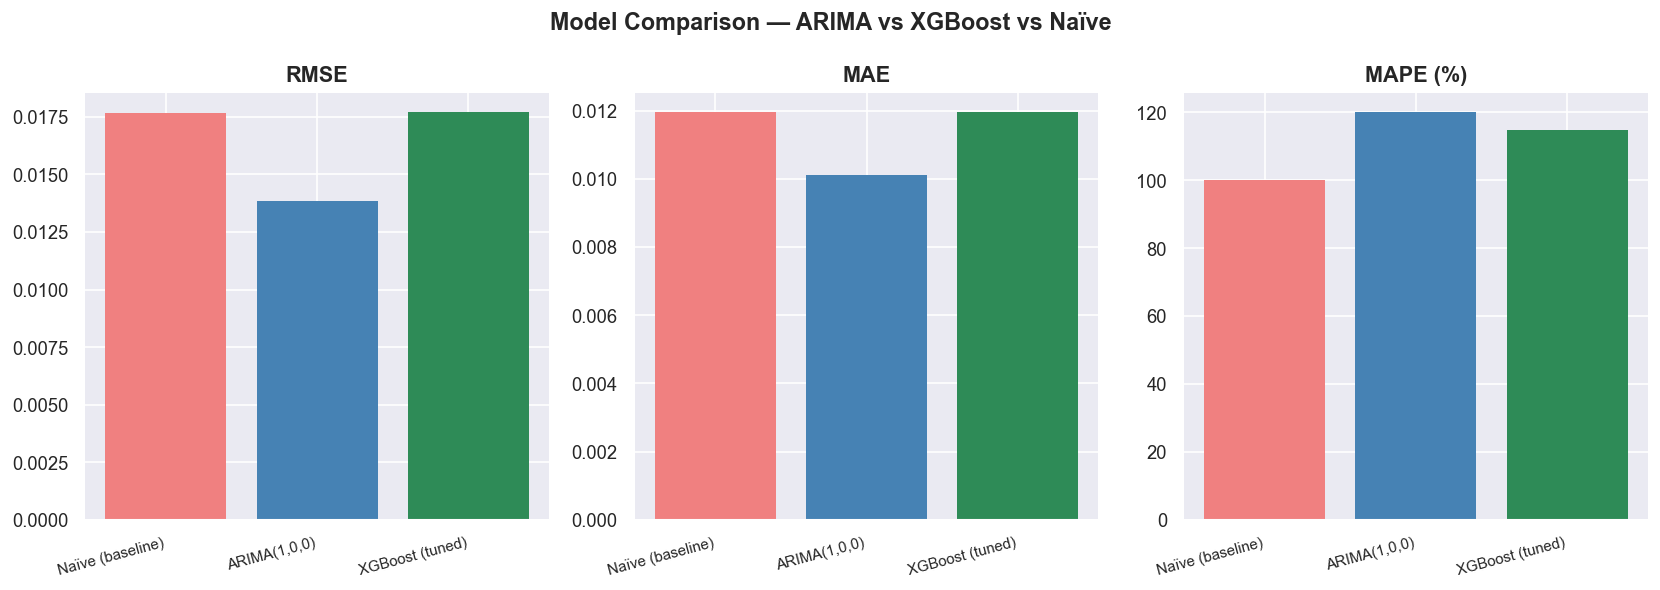

In [35]:
# pull ARIMA numbers from notebook 03 results
arima_rmse = 0.013851
arima_mae = 0.010115
arima_mape = 120.04

comparison = pd.DataFrame({
    "Model": ["Naïve (baseline)", "ARIMA(1,0,0)", "XGBoost (tuned)"],
    "RMSE": [0.017675, arima_rmse, rmse_tuned],
    "MAE": [0.011951, arima_mae, mae_tuned],
    "MAPE (%)": [100.00, arima_mape, mape_tuned],
    "Beats Naïve": ["—", "No (on full test)", "Marginally"],
})

print(comparison.to_string(index=False))

# visualize
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

models = comparison["Model"]
colors = ["lightcoral", "steelblue", "seagreen"]

for idx, metric in enumerate(["RMSE", "MAE", "MAPE (%)"]):
    axes[idx].bar(models, comparison[metric], color=colors, edgecolor="none")
    axes[idx].set_title(metric, fontsize=13, fontweight="bold")
    axes[idx].set_xticklabels(models, rotation=15, ha="right", fontsize=9)

plt.suptitle("Model Comparison — ARIMA vs XGBoost vs Naïve", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}15_model_comparison.png", bbox_inches="tight")
plt.show()

## Summary

Neither model beats the naive forecast in any meaningful way. MAPE tells the honest story: ARIMA at 120%, XGBoost at 115%, Naive at 100%. Both models confirm what I expected going in. Lagged returns and technical features carry almost no directional signal one a day to day basis. XGBoost's feature importance points to rolling volatility as the main signal, meaning the market prices risk more predictably than direction.